# 03 — Train a 5-second JSBSim skill classifier

This notebook loads the canonical trajectory shards written by
`02_generate_jsbsim_skill_dataset.ipynb` (also referred to as
`jsbsim_1v1_skill_dataset.ipynb`), makes leakage-safe **episode-grouped**
train/validation/test splits, and trains a GRU to identify the tactical skill shown in
each five-second window.

Only `MODEL_FEATURE_COLUMNS` are inputs. Commanded skills, native actions, and other
privileged columns are used solely as targets or audit metadata. Windows containing a
skill transition are excluded by default because they do not have a single unambiguous
class; set `BVR_KEEP_MIXED_WINDOWS=1` to label them by their final sample instead.


## 1. Imports and configuration

The default dataset path is the output path of notebook 02. Environment variables make
quick experiments reproducible without editing cells. A one-second stride creates
overlapping five-second windows *within* an episode; episodes never cross dataset
splits.

Training defaults to CPU because an incompatible CUDA/cuDNN native library can terminate a notebook kernel without raising a Python exception. After verifying the local PyTorch/CUDA installation, set `BVR_TRAIN_DEVICE=cuda` to opt in. `BVR_TORCH_THREADS` (default: at most four) limits native worker threads; both choices favor a stable notebook process.


In [1]:
import os
import sys

dll_dir = os.path.join(sys.prefix, "Library", "bin")
path_entries = os.environ.get("PATH", "").split(os.pathsep)

print("Python:", sys.executable)
print("CONDA_PREFIX:", os.environ.get("CONDA_PREFIX"))
print("DLL directory:", dll_dir)

print(
    "Library/bin in PATH:",
    any(
        os.path.normcase(os.path.normpath(p))
        == os.path.normcase(os.path.normpath(dll_dir))
        for p in path_entries
    )
)

print("\nFirst PATH entries:")
for p in path_entries[:10]:
    print(" ", p)

Python: C:\Users\theon\.conda\envs\trajectory-classification\python.exe
CONDA_PREFIX: C:\Users\theon\.conda\envs\trajectory-classification
DLL directory: C:\Users\theon\.conda\envs\trajectory-classification\Library\bin
Library/bin in PATH: True

First PATH entries:
  C:\Users\theon\.conda\envs\trajectory-classification
  C:\Users\theon\.conda\envs\trajectory-classification\Library\mingw-w64\bin
  C:\Users\theon\.conda\envs\trajectory-classification\Library\usr\bin
  C:\Users\theon\.conda\envs\trajectory-classification\Library\bin
  C:\Users\theon\.conda\envs\trajectory-classification\Scripts
  $Path$


In [2]:
path_entries

['C:\\Users\\theon\\.conda\\envs\\trajectory-classification',
 'C:\\Users\\theon\\.conda\\envs\\trajectory-classification\\Library\\mingw-w64\\bin',
 'C:\\Users\\theon\\.conda\\envs\\trajectory-classification\\Library\\usr\\bin',
 'C:\\Users\\theon\\.conda\\envs\\trajectory-classification\\Library\\bin',
 'C:\\Users\\theon\\.conda\\envs\\trajectory-classification\\Scripts',
 '$Path$']

In [3]:
import os
import sys
import torch

print("Python:", sys.executable)
print("CONDA_PREFIX:", os.environ.get("CONDA_PREFIX"))
print("PyTorch:", torch.__version__)
print("CUDA build:", torch.version.cuda)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Python: C:\Users\theon\.conda\envs\trajectory-classification\python.exe
CONDA_PREFIX: C:\Users\theon\.conda\envs\trajectory-classification
PyTorch: 2.14.0
CUDA build: 13.0
CUDA available: True
GPU: NVIDIA GeForce RTX 5080 Laptop GPU


In [4]:
import os
import sys

print("Python:", sys.executable)
print("CONDA_PREFIX:", os.environ.get("CONDA_PREFIX"))

dll_dir = os.path.join(sys.prefix, "Library", "bin")
path_entries = os.environ.get("PATH", "").split(os.pathsep)

print("DLL directory:", dll_dir)
print(
    "Library/bin in PATH:",
    any(p.lower() == dll_dir.lower() for p in path_entries)
)

print("\nFirst PATH entries:")
for p in path_entries[:10]:
    print(" ", p)

Python: C:\Users\theon\.conda\envs\trajectory-classification\python.exe
CONDA_PREFIX: C:\Users\theon\.conda\envs\trajectory-classification
DLL directory: C:\Users\theon\.conda\envs\trajectory-classification\Library\bin
Library/bin in PATH: True

First PATH entries:
  C:\Users\theon\.conda\envs\trajectory-classification
  C:\Users\theon\.conda\envs\trajectory-classification\Library\mingw-w64\bin
  C:\Users\theon\.conda\envs\trajectory-classification\Library\usr\bin
  C:\Users\theon\.conda\envs\trajectory-classification\Library\bin
  C:\Users\theon\.conda\envs\trajectory-classification\Scripts
  $Path$


In [5]:
import os
import sys

print("Python:", sys.executable)
print("CONDA_PREFIX:", os.environ.get("CONDA_PREFIX"))

dll_dir = os.path.join(sys.prefix, "Library", "bin")
paths = os.environ["PATH"].split(os.pathsep)

print("DLL directory:", dll_dir)
print(
    "Library/bin in PATH:",
    any(p.lower() == dll_dir.lower() for p in paths)
)

print("\nFirst 10 PATH entries:")
for p in paths[:10]:
    print(" ", p)

Python: C:\Users\theon\.conda\envs\trajectory-classification\python.exe
CONDA_PREFIX: C:\Users\theon\.conda\envs\trajectory-classification
DLL directory: C:\Users\theon\.conda\envs\trajectory-classification\Library\bin
Library/bin in PATH: True

First 10 PATH entries:
  C:\Users\theon\.conda\envs\trajectory-classification
  C:\Users\theon\.conda\envs\trajectory-classification\Library\mingw-w64\bin
  C:\Users\theon\.conda\envs\trajectory-classification\Library\usr\bin
  C:\Users\theon\.conda\envs\trajectory-classification\Library\bin
  C:\Users\theon\.conda\envs\trajectory-classification\Scripts
  $Path$


In [6]:
import os
import sys
from pathlib import Path

env = Path(sys.prefix)
conda_bin = env / "Library" / "bin"

# Put the Conda environment's DLLs ahead of the system CUDA installation.
os.environ["PATH"] = str(conda_bin) + os.pathsep + os.environ["PATH"]

# Python 3.8+ Windows DLL search path.
_conda_dll_handle = os.add_dll_directory(str(conda_bin))

import torch

print("PyTorch:", torch.__version__)
print("CUDA build:", torch.version.cuda)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.14.0
CUDA build: 13.0
CUDA available: True
GPU: NVIDIA GeForce RTX 5080 Laptop GPU


In [7]:
import os
import sys
from pathlib import Path

env = Path(sys.prefix)
dll_dir = env / "Library" / "bin"

print("Python executable:")
print(sys.executable)

print("\nsys.prefix:")
print(sys.prefix)

print("\nCONDA_PREFIX:")
print(os.environ.get("CONDA_PREFIX"))

print("\nConda DLL directory:")
print(dll_dir)
print("Exists:", dll_dir.exists())

print("\nIs Conda DLL directory in PATH?")
path_entries = os.environ.get("PATH", "").split(os.pathsep)
print(any(str(dll_dir).lower() == p.lower() for p in path_entries))

print("\nCUDA runtime DLLs:")
for p in dll_dir.glob("*cudart*.dll"):
    print(" ", p.name)

print("\nPyTorch DLLs:")
for name in ("c10.dll", "c10_cuda.dll", "torch_cpu.dll",
             "torch_cuda.dll", "torch_python.dll"):
    p = dll_dir / name
    print(f"{name:20s} exists={p.exists()}")

print("\nFirst 15 PATH entries:")
for p in path_entries[:15]:
    print(" ", p)

Python executable:
C:\Users\theon\.conda\envs\trajectory-classification\python.exe

sys.prefix:
C:\Users\theon\.conda\envs\trajectory-classification

CONDA_PREFIX:
C:\Users\theon\.conda\envs\trajectory-classification

Conda DLL directory:
C:\Users\theon\.conda\envs\trajectory-classification\Library\bin
Exists: True

Is Conda DLL directory in PATH?
True

CUDA runtime DLLs:
  cudart64_13.dll

PyTorch DLLs:
c10.dll              exists=True
c10_cuda.dll         exists=True
torch_cpu.dll        exists=True
torch_cuda.dll       exists=True
torch_python.dll     exists=True

First 15 PATH entries:
  C:\Users\theon\.conda\envs\trajectory-classification\Library\bin
  C:\Users\theon\.conda\envs\trajectory-classification
  C:\Users\theon\.conda\envs\trajectory-classification\Library\mingw-w64\bin
  C:\Users\theon\.conda\envs\trajectory-classification\Library\usr\bin
  C:\Users\theon\.conda\envs\trajectory-classification\Library\bin
  C:\Users\theon\.conda\envs\trajectory-classification\Scripts
  $

In [8]:
import sys
import torch
import torch._utils

print("Python executable :", sys.executable)
print("PyTorch file      :", torch.__file__)
print("PyTorch version   :", torch.__version__)
print("CUDA build        :", torch.version.cuda)
print("CUDA available    :", torch.cuda.is_available())
print("torch._utils file :", torch._utils.__file__)
print("Has torch._utils  :", hasattr(torch, "_utils"))

if torch.cuda.is_available():
    print("GPU               :", torch.cuda.get_device_name(0))

Python executable : C:\Users\theon\.conda\envs\trajectory-classification\python.exe
PyTorch file      : C:\Users\theon\.conda\envs\trajectory-classification\Lib\site-packages\torch\__init__.py
PyTorch version   : 2.14.0
CUDA build        : 13.0
CUDA available    : True
torch._utils file : C:\Users\theon\.conda\envs\trajectory-classification\Lib\site-packages\torch\_utils.py
Has torch._utils  : True
GPU               : NVIDIA GeForce RTX 5080 Laptop GPU


In [9]:
from __future__ import annotations

import json
import os
import random
from copy import deepcopy
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyarrow as pa
import torch
from sklearn.metrics import ConfusionMatrixDisplay, classification_report
from sklearn.preprocessing import StandardScaler
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

from bvr_behavior_prediction.data.observable_columns import MODEL_FEATURE_COLUMNS
from bvr_behavior_prediction.data.privileged_columns import PRIVILEGED_COLUMNS
from bvr_behavior_prediction.data.windows import episode_split

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "pyproject.toml").exists():
    REPO_ROOT = REPO_ROOT.parent
DATASET_DIR = Path(os.getenv(
    "BVR_TRAIN_DATASET",
    REPO_ROOT / "artifacts/datasets/bvr_f16_1v1_jsbsim_skills_v001",
))
OUTPUT_DIR = Path(os.getenv(
    "BVR_CLASSIFIER_OUTPUT", REPO_ROOT / "artifacts/models/jsbsim_skill_gru_v001"
))
WINDOW_S = 5.0
STRIDE_S = float(os.getenv("BVR_WINDOW_STRIDE_S", "1.0"))
KEEP_MIXED_WINDOWS = os.getenv("BVR_KEEP_MIXED_WINDOWS", "0") == "1"
BATCH_SIZE = int(os.getenv("BVR_BATCH_SIZE", "64"))
TORCH_THREADS = int(os.getenv("BVR_TORCH_THREADS", str(min(4, os.cpu_count() or 1))))
REQUESTED_DEVICE = os.getenv("BVR_TRAIN_DEVICE", "cpu").strip().lower()
EPOCHS = int(os.getenv("BVR_TRAIN_EPOCHS", "30"))
PATIENCE = int(os.getenv("BVR_EARLY_STOPPING_PATIENCE", "6"))
SEED = int(os.getenv("BVR_TRAIN_SEED", "20260911"))

if TORCH_THREADS < 1:
    raise ValueError("BVR_TORCH_THREADS must be at least 1")
if REQUESTED_DEVICE.startswith("cuda") and not torch.cuda.is_available():
    raise RuntimeError(
        f"BVR_TRAIN_DEVICE={REQUESTED_DEVICE!r} requires CUDA, but this PyTorch "
        "installation cannot access it. Use BVR_TRAIN_DEVICE=cpu or install a "
        "CUDA-compatible PyTorch build."
    )

# GRU kernels and BLAS libraries can exhaust notebook process resources when they
# create a worker for every host core. A small explicit pool is predictable, while
# CUDA remains available as an opt-in after its native stack has been verified.
torch.set_num_threads(TORCH_THREADS)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if REQUESTED_DEVICE.startswith("cuda"):
    torch.cuda.manual_seed_all(SEED)
DEVICE = torch.device(REQUESTED_DEVICE)
print({
    "dataset": str(DATASET_DIR), "device": str(DEVICE), "seed": SEED,
    "torch_threads": torch.get_num_threads(),
})


{'dataset': 'C:\\Users\\theon\\Trajectory_Classification\\artifacts\\datasets\\bvr_f16_1v1_jsbsim_skills_v001', 'device': 'cpu', 'seed': 20260911, 'torch_threads': 4}


## 2. Load and validate the canonical trajectory shards


In [10]:
shards = sorted((DATASET_DIR / "trajectories").glob("*.parquet"))
if not shards:
    raise FileNotFoundError(
        f"No trajectory shards found under {DATASET_DIR / 'trajectories'}. "
        "Run notebooks/02_generate_jsbsim_skill_dataset.ipynb first or set "
        "BVR_TRAIN_DATASET."
    )
try:
    trajectories = pd.concat((pd.read_parquet(path) for path in shards), ignore_index=True)
except pa.ArrowKeyError as error:
    raise RuntimeError(
        "PyArrow's legacy extension registry is incompatible with this pandas session. "
        "Install the project dependencies (which require pyarrow>=14.0.1), restart the "
        "notebook kernel, and run all cells again."
    ) from error
required = {"episode_id", "time_s", "tactical_label", *MODEL_FEATURE_COLUMNS}
missing = required.difference(trajectories.columns)
assert not missing, f"Missing required columns: {sorted(missing)}"
assert set(MODEL_FEATURE_COLUMNS).isdisjoint(PRIVILEGED_COLUMNS)
trajectories = trajectories.sort_values(["episode_id", "time_s"]).reset_index(drop=True)
feature_frame = trajectories.loc[:, MODEL_FEATURE_COLUMNS].replace([np.inf, -np.inf], np.nan)
assert feature_frame.notna().all().all(), "Observable features contain NaN or infinity"
print(f"Loaded {len(trajectories):,} samples from {trajectories.episode_id.nunique()} episodes")
display(trajectories.groupby("tactical_label").agg(samples=("time_s", "size"), episodes=("episode_id", "nunique")))


Loaded 45,100 samples from 100 episodes


,samples,episodes
tactical_label,,
BEAM,7219,32
CRANK_LEFT,7066,32
CRANK_RIGHT,7009,30
EXTEND,9072,41
MAINTAIN,7366,33
PURSUE,7368,32


## 3. Split episodes, then construct five-second windows

Splitting before windowing prevents overlapping samples—or any samples from the same
flight—from leaking across train, validation, and test. Cadence is inferred from data
and checked per episode. Each retained window contains exactly `round(5 / dt)` samples.
By default, transition-spanning windows are counted for auditing and then dropped.


In [11]:
episode_ids = trajectories["episode_id"].drop_duplicates().tolist()
if len(episode_ids) < 3:
    raise ValueError("At least three episodes are required for non-empty train/validation/test splits")
split_ids = episode_split(episode_ids, seed=SEED, fractions=(0.70, 0.15, 0.15))
assert all(split_ids.values()), "Need enough episodes for every split"
assert not (set(split_ids["train"]) & set(split_ids["validation"]))
assert not (set(split_ids["train"]) & set(split_ids["test"]))
assert not (set(split_ids["validation"]) & set(split_ids["test"]))

sample_deltas = trajectories.groupby("episode_id")["time_s"].diff().dropna()
SAMPLE_DT_S = float(sample_deltas.median())
assert SAMPLE_DT_S > 0 and np.allclose(sample_deltas, SAMPLE_DT_S, atol=1e-6), "Irregular sample cadence"
WINDOW_SAMPLES = int(round(WINDOW_S / SAMPLE_DT_S))
STRIDE_SAMPLES = max(1, int(round(STRIDE_S / SAMPLE_DT_S)))
assert WINDOW_SAMPLES >= 2
print({"sample_dt_s": SAMPLE_DT_S, "window_samples": WINDOW_SAMPLES, "stride_samples": STRIDE_SAMPLES})


{'sample_dt_s': 0.10000000000000053, 'window_samples': 50, 'stride_samples': 10}


In [12]:
LABELS = json.loads((DATASET_DIR / "label_map.json").read_text())["tactical"]
label_to_index = {label: index for index, label in enumerate(LABELS)}
unknown = set(trajectories["tactical_label"].unique()).difference(label_to_index)
assert not unknown, f"Labels absent from label_map.json: {sorted(unknown)}"


def make_windows(frame, allowed_episode_ids):
    sequences, labels, metadata = [], [], []
    mixed_count = 0
    selected = frame[frame["episode_id"].isin(allowed_episode_ids)]
    for episode_id, episode in selected.groupby("episode_id", sort=False):
        episode = episode.sort_values("time_s")
        values = episode.loc[:, MODEL_FEATURE_COLUMNS].to_numpy(dtype=np.float32)
        targets = episode["tactical_label"].to_numpy()
        times = episode["time_s"].to_numpy()
        for start in range(0, len(episode) - WINDOW_SAMPLES + 1, STRIDE_SAMPLES):
            stop = start + WINDOW_SAMPLES
            window_targets = targets[start:stop]
            mixed = np.any(window_targets != window_targets[0])
            mixed_count += int(mixed)
            if mixed and not KEEP_MIXED_WINDOWS:
                continue
            sequences.append(values[start:stop])
            labels.append(label_to_index[window_targets[-1]])
            metadata.append({
                "episode_id": episode_id,
                "start_time_s": float(times[start]),
                "end_time_s": float(times[stop - 1]),
                "mixed_skill": bool(mixed),
            })
    if not sequences:
        raise ValueError("No windows were produced; check episode duration and transition filtering")
    return np.stack(sequences), np.asarray(labels, dtype=np.int64), pd.DataFrame(metadata), mixed_count

raw = {}
for split_name, ids in split_ids.items():
    x, y, metadata, mixed = make_windows(trajectories, ids)
    raw[split_name] = {"x": x, "y": y, "metadata": metadata}
    print(split_name, {"episodes": len(ids), "windows": len(y), "excluded_mixed": mixed})

assert set(raw["train"]["metadata"].episode_id).isdisjoint(raw["validation"]["metadata"].episode_id)
assert set(raw["train"]["metadata"].episode_id).isdisjoint(raw["test"]["metadata"].episode_id)


train {'episodes': 70, 'windows': 2522, 'excluded_mixed': 348}
validation {'episodes': 15, 'windows': 541, 'excluded_mixed': 74}
test {'episodes': 15, 'windows': 540, 'excluded_mixed': 75}


## 4. Fit normalization on training data only

The scaler sees training timesteps only. It is then applied without refitting to the
validation and held-out test windows.


In [13]:
scaler = StandardScaler()
train_shape = raw["train"]["x"].shape
scaler.fit(raw["train"]["x"].reshape(-1, train_shape[-1]))

loaders = {}
for split_name, values in raw.items():
    x = values["x"]
    scaled = scaler.transform(x.reshape(-1, x.shape[-1])).reshape(x.shape).astype(np.float32)
    dataset = TensorDataset(torch.from_numpy(scaled), torch.from_numpy(values["y"]))
    generator = torch.Generator().manual_seed(SEED)
    loaders[split_name] = DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=split_name == "train",
        generator=generator if split_name == "train" else None,
    )

print("Train tensor:", tuple(loaders["train"].dataset.tensors[0].shape))


Train tensor: (2522, 50, 21)


## 5. Define and train a GRU classifier


01 train loss=1.5906 acc=0.333 val loss=1.8087 acc=0.329
02 train loss=1.2658 acc=0.472 val loss=1.8110 acc=0.383
03 train loss=0.9334 acc=0.632 val loss=1.9989 acc=0.425
04 train loss=0.5699 acc=0.774 val loss=2.0376 acc=0.399
05 train loss=0.3552 acc=0.874 val loss=2.5089 acc=0.399
06 train loss=0.2721 acc=0.911 val loss=2.3498 acc=0.431
07 train loss=0.2022 acc=0.937 val loss=2.9487 acc=0.359
Early stopping


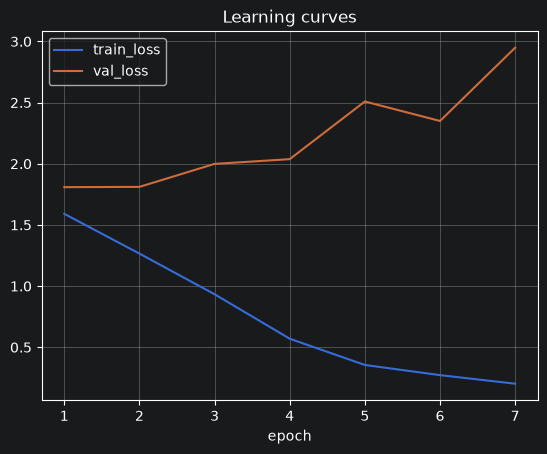

In [15]:
DEVICE = 'cuda'

class SkillGRU(nn.Module):
    def __init__(self, input_dim, class_count, hidden_dim=128, layers=2, dropout=0.2):
        super().__init__()
        self.encoder = nn.GRU(
            input_dim, hidden_dim, num_layers=layers, batch_first=True,
            dropout=dropout if layers > 1 else 0.0,
        )
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(hidden_dim, class_count)

    def forward(self, sequence):
        _, hidden = self.encoder(sequence)
        return self.classifier(self.dropout(hidden[-1]))


model = SkillGRU(len(MODEL_FEATURE_COLUMNS), len(LABELS)).to(DEVICE)
counts = np.bincount(raw["train"]["y"], minlength=len(LABELS))
weights = counts.sum() / (len(LABELS) * np.maximum(counts, 1))
criterion = nn.CrossEntropyLoss(weight=torch.tensor(weights, dtype=torch.float32, device=DEVICE))
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)


def run_epoch(loader, training=False):
    model.train(training)
    total_loss = total_correct = total = 0
    for features, target in loader:
        features, target = features.to(DEVICE), target.to(DEVICE)
        if training:
            optimizer.zero_grad(set_to_none=True)
        with torch.set_grad_enabled(training):
            logits = model(features)
            loss = criterion(logits, target)
            if training:
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
        total_loss += loss.item() * len(target)
        total_correct += (logits.argmax(1) == target).sum().item()
        total += len(target)
    return {"loss": total_loss / total, "accuracy": total_correct / total}


history, best_state, best_val_loss, stale_epochs = [], None, float("inf"), 0
for epoch in range(1, EPOCHS + 1):
    train_metrics = run_epoch(loaders["train"], training=True)
    val_metrics = run_epoch(loaders["validation"])
    history.append({"epoch": epoch, **{f"train_{k}": v for k, v in train_metrics.items()},
                    **{f"val_{k}": v for k, v in val_metrics.items()}})
    print(f"{epoch:02d} train loss={train_metrics['loss']:.4f} acc={train_metrics['accuracy']:.3f} "
          f"val loss={val_metrics['loss']:.4f} acc={val_metrics['accuracy']:.3f}")
    if val_metrics["loss"] < best_val_loss - 1e-4:
        best_val_loss = val_metrics["loss"]
        best_state = deepcopy(model.state_dict())
        stale_epochs = 0
    else:
        stale_epochs += 1
        if stale_epochs >= PATIENCE:
            print("Early stopping")
            break

assert best_state is not None
model.load_state_dict(best_state)
history = pd.DataFrame(history)
history.plot(x="epoch", y=["train_loss", "val_loss"], grid=True, title="Learning curves")
plt.show()


## 6. Evaluate once on the held-out test set

The test split is not used for normalization, model selection, or early stopping.
Class-wise metrics and the confusion matrix expose performance hidden by aggregate
accuracy.


              precision    recall  f1-score   support

    MAINTAIN      0.000     0.000     0.000       104
      PURSUE      0.000     0.000     0.000        69
        BEAM      0.464     0.280     0.349        93
  CRANK_LEFT      0.000     0.000     0.000        43
 CRANK_RIGHT      0.000     0.000     0.000        96
      EXTEND      0.689     0.526     0.597       135

    accuracy                          0.180       540
   macro avg      0.192     0.134     0.158       540
weighted avg      0.252     0.180     0.209       540



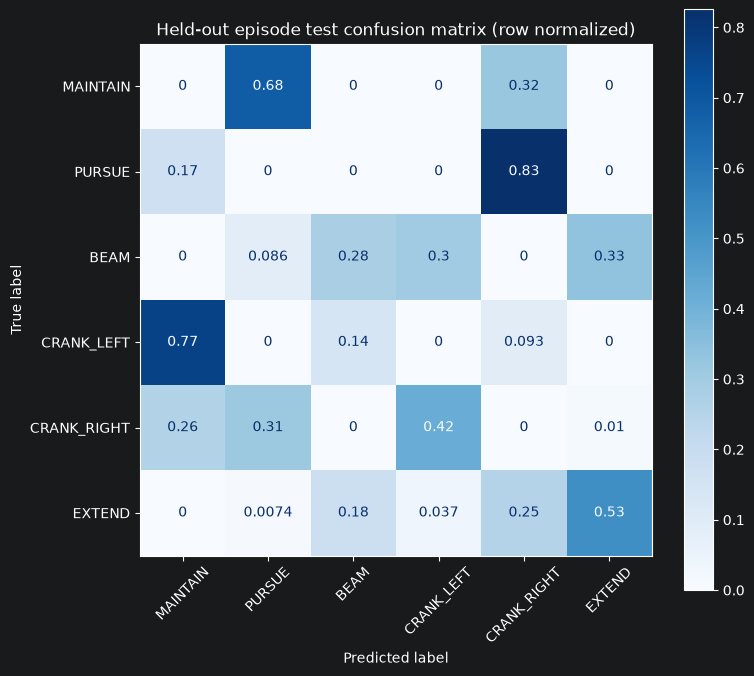

In [16]:
def predict(loader):
    model.eval()
    actual, predicted = [], []
    with torch.no_grad():
        for features, target in loader:
            logits = model(features.to(DEVICE))
            actual.extend(target.numpy().tolist())
            predicted.extend(logits.argmax(1).cpu().numpy().tolist())
    return np.asarray(actual), np.asarray(predicted)


y_test, y_pred = predict(loaders["test"])
print(classification_report(
    y_test, y_pred, labels=np.arange(len(LABELS)), target_names=LABELS,
    zero_division=0, digits=3,
))
fig, ax = plt.subplots(figsize=(8, 7))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, labels=np.arange(len(LABELS)), display_labels=LABELS,
    normalize="true", xticks_rotation=45, cmap="Blues", ax=ax,
)
ax.set_title("Held-out episode test confusion matrix (row normalized)")
plt.tight_layout()
plt.show()


## 7. Save the reproducible training bundle

The bundle contains the selected model, training-only normalization statistics, exact
episode assignment, class order, feature order, window settings, and learning history.


In [17]:
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
torch.save({
    "model_state_dict": model.state_dict(),
    "model_config": {"input_dim": len(MODEL_FEATURE_COLUMNS), "class_count": len(LABELS),
                     "hidden_dim": 128, "layers": 2, "dropout": 0.2},
    "feature_columns": list(MODEL_FEATURE_COLUMNS),
    "labels": LABELS,
    "window_samples": WINDOW_SAMPLES,
    "sample_dt_s": SAMPLE_DT_S,
}, OUTPUT_DIR / "model.pt")
(OUTPUT_DIR / "preprocessing.json").write_text(json.dumps({
    "feature_columns": list(MODEL_FEATURE_COLUMNS),
    "mean": scaler.mean_.tolist(),
    "scale": scaler.scale_.tolist(),
}, indent=2))
(OUTPUT_DIR / "split.json").write_text(json.dumps({
    "seed": SEED, "fractions": {"train": 0.70, "validation": 0.15, "test": 0.15},
    "episode_ids": split_ids,
    "window_s": WINDOW_S, "stride_s": STRIDE_S,
    "keep_mixed_windows": KEEP_MIXED_WINDOWS,
}, indent=2))
history.to_csv(OUTPUT_DIR / "history.csv", index=False)
for split_name, values in raw.items():
    values["metadata"].assign(label=[LABELS[index] for index in values["y"]]).to_parquet(
        OUTPUT_DIR / f"{split_name}_windows.parquet", index=False
    )
print("Saved training bundle to", OUTPUT_DIR.resolve())


Saved training bundle to C:\Users\theon\Trajectory_Classification\artifacts\models\jsbsim_skill_gru_v001


## Interpretation notes

* Report results as episode-held-out performance, not as independent random-window performance.
* Inspect the per-class report: broad accuracy can hide failure on rare skills.
* Mixed windows are useful for a future transition or multi-label model, but a single-label
  classifier should not silently train on them.
* This synthetic pilot validates the pipeline; it does not establish real-world tactical
  generalisation.
